# 3. El perceptrón como clasificador lineal

**Pregunta guía:** ¿qué geometría produce una neurona con activación umbral?

![Dos regiones separadas por una frontera lineal](imagenes/frontera_lineal.png)

La condición $w^Tx+b=0$ define la **frontera de decisión**. En dos dimensiones es una recta; en tres, un plano; en dimensiones superiores, un hiperplano. A cada lado, el signo determina una clase.

In [1]:
import torch
import matplotlib.pyplot as plt
AMARILLO, NEGRO, BLANCO, GRIS = "#F9C80E", "#111111", "#FFFFFF", "#B7B7B7"
torch.set_printoptions(precision=3, sci_mode=False)
print(f"PyTorch {torch.__version__}")

PyTorch 2.14.0


## Un perceptrón completamente especificado

No vamos a entrenarlo: fijaremos sus parámetros para estudiar su comportamiento. Con $w=(1,1)$ y $b=-1$, la frontera es $x_1+x_2=1$.

In [2]:
w, b = torch.tensor([1.0, 1.0]), torch.tensor(-1.0)
def perceptron(X):
    puntuacion = X @ w + b
    return puntuacion, (puntuacion >= 0).to(torch.int)

ejemplos = torch.tensor([[0.1, 0.2], [0.4, 0.8], [0.7, 0.6], [0.9, 0.3]])
puntuaciones, clases = perceptron(ejemplos)
for x, z, clase in zip(ejemplos, puntuaciones, clases):
    print(f"x={x.tolist()} · z={z.item():+.2f} · clase={clase.item()}")

x=[0.10000000149011612, 0.20000000298023224] · z=-0.70 · clase=0
x=[0.4000000059604645, 0.800000011920929] · z=+0.20 · clase=1
x=[0.699999988079071, 0.6000000238418579] · z=+0.30 · clase=1
x=[0.8999999761581421, 0.30000001192092896] · z=+0.20 · clase=1


## Visualizar la decisión

El vector $w$ es perpendicular a la frontera y apunta hacia la región clasificada como 1. El sesgo cambia la posición sin modificar la orientación.

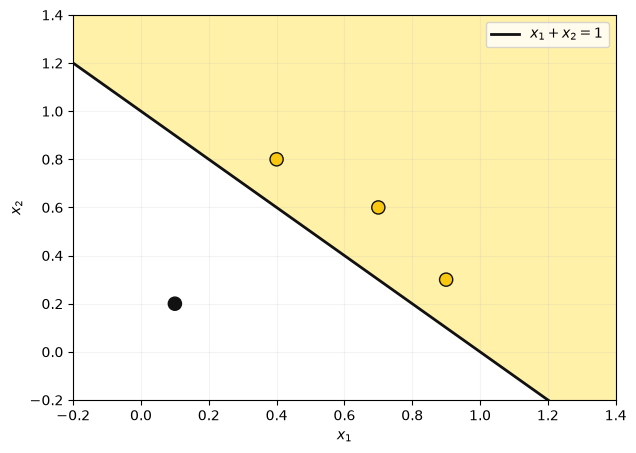

In [3]:
eje = torch.linspace(-0.2, 1.4, 250)
gx, gy = torch.meshgrid(eje, eje, indexing="xy")
_, region = perceptron(torch.stack([gx.flatten(), gy.flatten()], dim=1))
fig, ax = plt.subplots(figsize=(7, 5))
ax.contourf(gx, gy, region.reshape(gx.shape), levels=[-.5,.5,1.5], colors=[BLANCO,"#FFF1A8"])
ax.plot(eje, 1-eje, color=NEGRO, linewidth=2, label=r"$x_1+x_2=1$")
ax.scatter(ejemplos[:,0], ejemplos[:,1], c=[NEGRO if c==0 else AMARILLO for c in clases],
           edgecolor=NEGRO, s=90, zorder=3)
ax.set(xlabel="$x_1$", ylabel="$x_2$", xlim=(-.2,1.4), ylim=(-.2,1.4))
ax.legend(); ax.grid(alpha=.15)
plt.savefig("imagenes/decision_perceptron.png", dpi=160, bbox_inches="tight")
plt.show()

## Puertas lógicas

AND y OR son linealmente separables. El mismo peso $(1,1)$ y distintos sesgos producen ambas decisiones.

In [4]:
binarios = torch.tensor([[0.,0.],[0.,1.],[1.,0.],[1.,1.]])
for nombre, sesgo in {"AND": -1.5, "OR": -0.5}.items():
    salida = ((binarios @ torch.tensor([1.,1.]) + sesgo) >= 0).to(torch.int)
    print(nombre, ":", salida.tolist())

AND : [0, 0, 0, 1]
OR : [0, 1, 1, 1]


## Límite estructural

XOR asigna la misma clase a esquinas opuestas. Ninguna recta separa simultáneamente esas parejas. No es cuestión de elegir mejor los pesos: una neurona umbral solo expresa separaciones lineales.

## Comprueba tu comprensión

1. Dibuja la frontera de $w=(2,-1)$ y $b=0$.
2. ¿Qué cambia al multiplicar $w$ y $b$ por un valor positivo? ¿Y negativo?
3. Encuentra pesos y sesgo para NAND.
4. Explica por qué XOR exige combinar decisiones.

**Conclusión:** el perceptrón es interpretable, pero su capacidad queda limitada por una frontera lineal.